In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
def file2matrix(filename):
    train_x, train_y = [], []
    with open(filename, 'r') as f:
        for line in f.readlines():
            line = line.strip().split('\t')
            train_x.append(line[:3])
            train_y.append(int(line[-1]))
    train_x = np.array(train_x, dtype=float)
    train_y = np.array(train_y)
    return train_x, train_y

In [2]:
x, y = file2matrix('datingTestSet2.txt')
print(x[:5])

[[4.0920000e+04 8.3269760e+00 9.5395200e-01]
 [1.4488000e+04 7.1534690e+00 1.6739040e+00]
 [2.6052000e+04 1.4418710e+00 8.0512400e-01]
 [7.5136000e+04 1.3147394e+01 4.2896400e-01]
 [3.8344000e+04 1.6697880e+00 1.3429600e-01]]


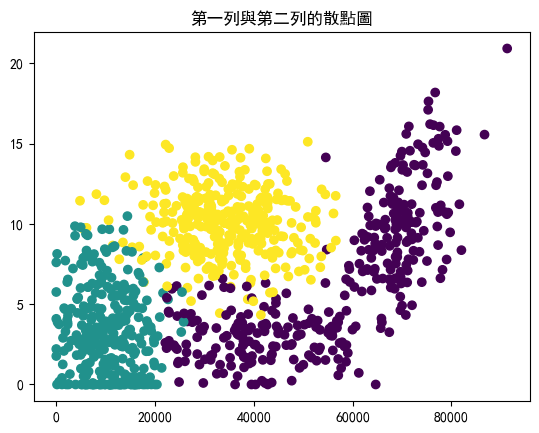

In [3]:
plt.scatter(x[:,0], x[:,1],c=y)
plt.title('第一列與第二列的散點圖')
plt.show()

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score

In [5]:
def knn0(x_train,y_train,x_test,y_test):
    knn = KNeighborsClassifier()
    knn.fit(x_train, y_train)
    return knn.score(x_test, y_test)

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y)
print(x_train.shape, x_test.shape)

(750, 3) (250, 3)


In [8]:
knn0(x_train,y_train,x_test,y_test)

0.776

In [9]:
def knn1(x, y):
    knn=KNeighborsClassifier(5)
    scores = cross_val_score(knn, x, y, cv=10, scoring='accuracy')
    return scores.mean()

In [10]:
knn1(x,y)

np.float64(0.7860000000000001)

## 不同數量的近鄰對正確率的影響

In [11]:
def knumsTest(x,y):
    k_range = range(1, 30, 2)
    k_scores = []
    for k in k_range:
        knn = KNeighborsClassifier(k)
        scores = cross_val_score(knn, x, y, cv=10, scoring='accuracy')
        k_scores.append(scores.mean())
    return k_range, k_scores

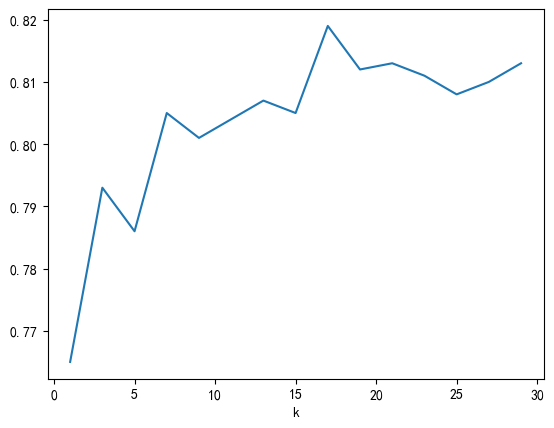

In [12]:
acc = knumsTest(x,y)
plt.plot(acc[0], acc[1])
plt.xlabel('k')
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xc = scaler.fit_transform(x)
print(xc[:5])

[[ 0.33193158  0.41660188  0.24523407]
 [-0.87247784  0.13992897  1.69385734]
 [-0.34554872 -1.20667094 -0.05422437]
 [ 1.89102937  1.55309196 -0.81110001]
 [ 0.2145527  -1.15293589 -1.40400471]]


In [14]:
def knn2(x, y):
    knn = KNeighborsClassifier(17)
    scores = cross_val_score(knn, x, y, cv=10, scoring='accuracy')
    return scores.mean()

In [15]:
knn2(xc, y)

np.float64(0.9470000000000001)

In [20]:
import numpy as np

def datingClassTest1(test):
    # Assuming test_data is a NumPy array or DataFrame
    test_data = np.array(test)  # Convert list to NumPy array if necessary
    min_value = np.min(test_data, axis=0)  # Ensure axis is correctly specified
    print(min_value)

# Example usage
test = [40920, 8.326976, 0.953952]
datingClassTest1(test)

0.953952


In [21]:
from sklearn.preprocessing import MinMaxScaler
def datingClassTest(test):
    x, y = file2matrix('datingTestSet2.txt')
    xmin = np.min(x, axis=0)
    xmax = np.max(x, axis=0)
    mm = MinMaxScaler()
    test = np.array(test)
    test = (test-xmin)/(xmax-xmin)
    test = test.reshape(1,3)
    xc = mm.fit_transform(x)
    knn=KNeighborsClassifier(17)
    knn.fit(xc,y)
    result = knn.predict(test)
    return result[0]

In [23]:
test = [40920,8.326976,0.953952]
datingClassTest(test)

np.int64(3)

In [25]:
test = [20920,4.326976,0.53952]
datingClassTest(test)

np.int64(2)

### 项目案例2: 手写数字识别系统

```
第一步，收集数据

目录 trainingDigits 中包含了大约 2000 个例子，每个例子内容如下图所示，每个数字大约有 200 个样本；目录 testDigits 中包含了大约 900 个测试数据。

```

In [27]:
def text2vector(filename):
    vec = []
    with open(filename,'r') as f:
        text = f.read()
    vec = list(text.replace('\n',''))
    vec = np.array(vec)
    vec = vec.astype(int)
    return vec

text2vector(r'D:\class\ml\digits\trainingDigits\0_0.txt')

array([0, 0, 0, ..., 0, 0, 0])

#### 執行前, 須將 digits.zip 解壓縮, 把測試集和訓練集放置至本目錄

In [35]:
import os
def handwritingClassTest():
    # 1. 导入训练数据
    train_labels = []
    train_data = []
    trainingFileList = os.listdir('trainingDigits')  # load the training set
    for item in trainingFileList:
        train_data.append(text2vector('trainingDigits/'+item))
        train_labels.append(int(item.split('_')[0]))
     # 2. 导入测试数据
    test_labels = []
    test_data = []
    testFileList = os.listdir('testDigits')  # iterate through the test set
    for item in testFileList:
        test_data.append(text2vector('testDigits/'+item))
        test_labels.append(int(item.split('_')[0]))
    knn=KNeighborsClassifier(21)
    knn.fit(train_data,train_labels)
    return knn.score(test_data,test_labels)


handwritingClassTest()

0.9693446088794926